In [2]:
pip install prince


Note: you may need to restart the kernel to use updated packages.


Jeu de données :
   Individu    Age Niveau_etudes Activite
0      Ind1  18-25           Bac   Cinéma
1      Ind2  26-35           Bac  Théâtre
2      Ind3  36-50           Bac  Concert
3      Ind4  51-65           Bac    Musée
4      Ind5  18-25           Bac   Cinéma
5      Ind6  26-35       Licence  Théâtre
6      Ind7  36-50       Licence  Concert
7      Ind8  51-65       Licence    Musée
8      Ind9  18-25       Licence   Cinéma
9     Ind10  26-35       Licence  Théâtre
10    Ind11  36-50        Master  Concert
11    Ind12  51-65        Master    Musée
12    Ind13  18-25        Master   Cinéma
13    Ind14  26-35        Master  Théâtre
14    Ind15  36-50        Master  Concert
15    Ind16  51-65      Doctorat    Musée
16    Ind17  18-25      Doctorat   Cinéma
17    Ind18  26-35      Doctorat  Théâtre
18    Ind19  36-50      Doctorat  Concert
19    Ind20  51-65      Doctorat    Musée

Valeurs propres (inerties) :
[0.69148542 0.69148542]

Pourcentage d’inertie expliquée :
[0.5 0.5]

I

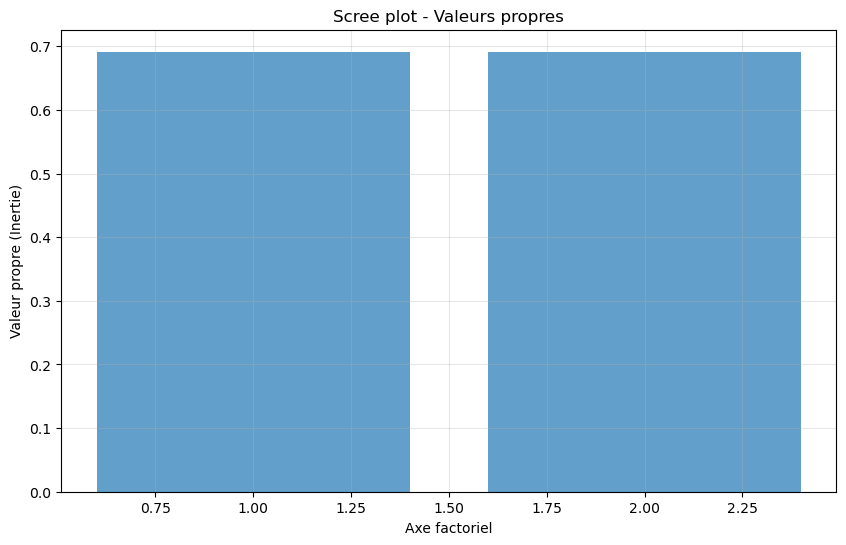

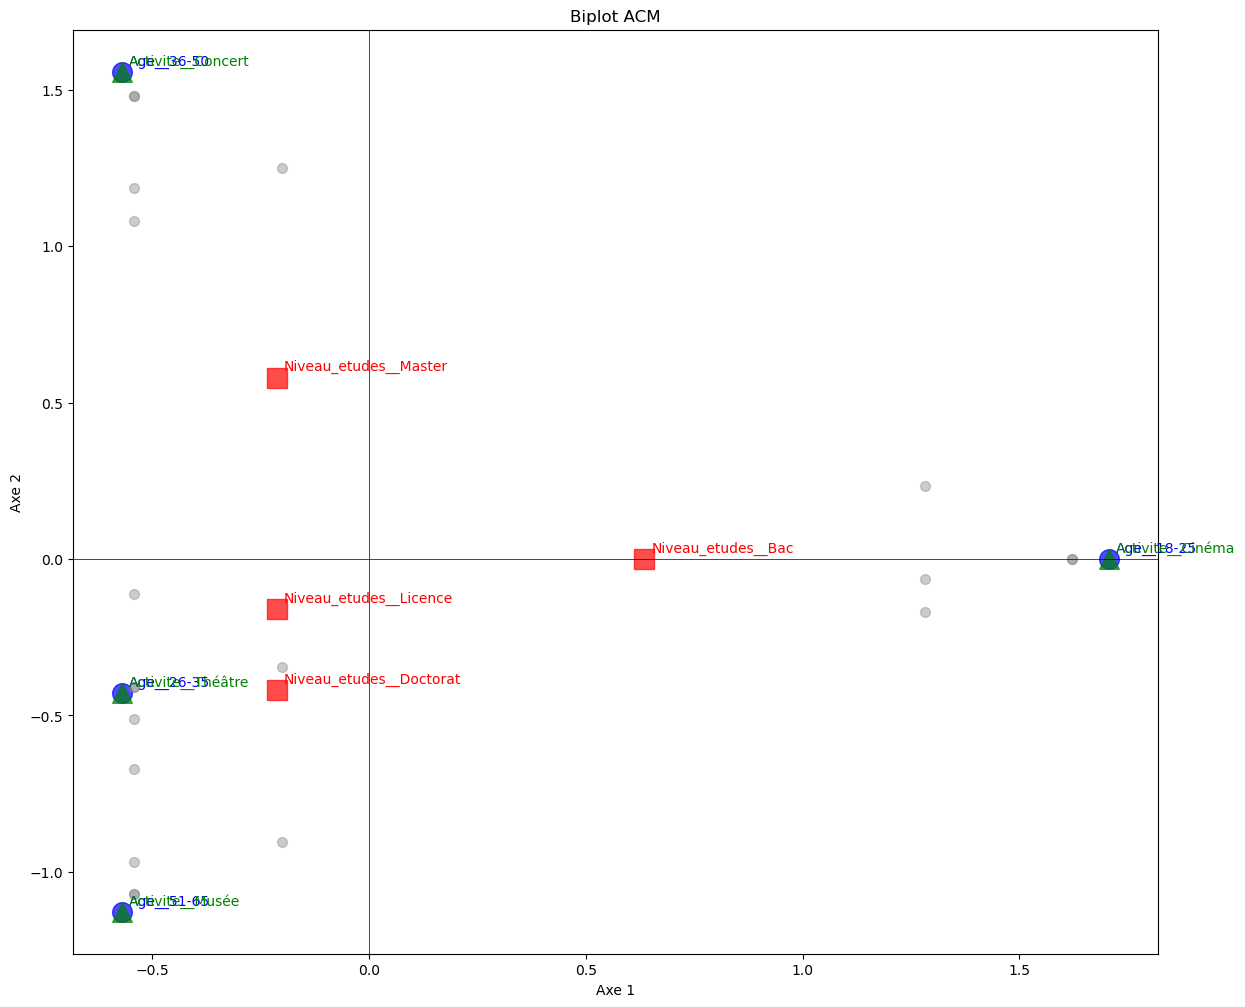

Dimensions du tableau disjonctif complet : (20, 12)

Dimensions de la matrice de Burt : (12, 12)

Matrice des V de Cramer :
               Age  Niveau_etudes  Activite
Age            1.0            0.0       1.0
Niveau_etudes  0.0            1.0       0.0
Activite       1.0            0.0       1.0


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prince import MCA
from sklearn.preprocessing import OneHotEncoder
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import chi2_contingency

# Création du jeu de données
data = {
    'Individu': [f'Ind{i}' for i in range(1, 21)],
    'Age': ['18-25', '26-35', '36-50', '51-65'] * 5,
    'Niveau_etudes': (['Bac']*5 + ['Licence']*5 + ['Master']*5 + ['Doctorat']*5)[:20],
    'Activite': ['Cinéma', 'Théâtre', 'Concert', 'Musée'] * 5
}

donnees = pd.DataFrame(data)
print("Jeu de données :")
print(donnees)
print()

# ACM avec le package prince
mca = MCA(n_components=2, random_state=42)
mca = mca.fit(donnees[['Age', 'Niveau_etudes', 'Activite']])

# Valeurs propres et inertie
# Valeurs propres
print("Valeurs propres (inerties) :")
print(mca.eigenvalues_)
print()

# Calcul manuel du pourcentage d’inertie expliquée
inertie_pourcent = mca.eigenvalues_ / np.sum(mca.eigenvalues_)
print("Pourcentage d’inertie expliquée :")
print(inertie_pourcent)
print()

# Inertie expliquée cumulative
print("Inertie expliquée cumulative :")
print(np.cumsum(inertie_pourcent))
print()


# Coordonnées des modalités
modalites_coords = mca.column_coordinates(donnees[['Age', 'Niveau_etudes', 'Activite']])
print("Coordonnées des modalités :")
print(modalites_coords.round(4))
print()

# Coordonnées des individus
individus_coords = mca.row_coordinates(donnees[['Age', 'Niveau_etudes', 'Activite']])
individus_coords['Individu'] = donnees['Individu']
print("Coordonnées des individus (extrait) :")
print(individus_coords.head().round(4))
print()

# Contributions
print("Contributions des modalités aux axes :")
contrib_modalites = mca.column_contributions_.round(4)
print(contrib_modalites)
print()

# Graphique des valeurs propres (Scree plot)
plt.figure(figsize=(10, 6))
inerties = mca.eigenvalues_
plt.bar(range(1, len(inerties) + 1), inerties, alpha=0.7, align='center')
plt.xlabel('Axe factoriel')
plt.ylabel('Valeur propre (Inertie)')
plt.title('Scree plot - Valeurs propres')
plt.grid(True, alpha=0.3)
plt.show()

# Biplot ACM avec matplotlib
fig, ax = plt.subplots(figsize=(14, 12))

# Projection des modalités
for idx, row in modalites_coords.iterrows():
    if 'Age' in idx:
        color = 'blue'
        marker = 'o'
    elif 'Niveau_etudes' in idx:
        color = 'red'
        marker = 's'
    else:
        color = 'green'
        marker = '^'

    ax.scatter(row[0], row[1], c=color, marker=marker, s=200, alpha=0.7)
    ax.annotate(idx, (row[0], row[1]), fontsize=10, color=color,
                xytext=(5, 5), textcoords='offset points')

# Projection des individus
ax.scatter(individus_coords[0], individus_coords[1],
           c='gray', alpha=0.4, s=50)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Axe 1')
ax.set_ylabel('Axe 2')
ax.set_title('Biplot ACM')
plt.show()

# Tableau disjonctif complet
encoder = OneHotEncoder(sparse_output=False)
tdc = encoder.fit_transform(donnees[['Age', 'Niveau_etudes', 'Activite']])
tdc_df = pd.DataFrame(tdc, columns=encoder.get_feature_names_out())
print("Dimensions du tableau disjonctif complet :", tdc.shape)
print()

# Matrice de Burt
burt_matrix = np.dot(tdc.T, tdc)
print("Dimensions de la matrice de Burt :", burt_matrix.shape)
print()

# V de Cramer
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

variables = ['Age', 'Niveau_etudes', 'Activite']
cramer_matrix = pd.DataFrame(index=variables, columns=variables, dtype=float)

for var1 in variables:
    for var2 in variables:
        if var1 == var2:
            cramer_matrix.loc[var1, var2] = 1.0
        else:
            cramer_matrix.loc[var1, var2] = cramers_v(donnees[var1], donnees[var2])

print("Matrice des V de Cramer :")
print(cramer_matrix.round(3))
